## Voorspel aandeelprijs volgend uur

Setup

In [1]:
import requests
import pandas as pd 
import datetime

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

## Scrape Yahoo Finance voor historische data

In [2]:

# timestamp now
timestamp = int(datetime.datetime.now().timestamp())
# timestamp 100 days ago
timestamp_100_days_ago = timestamp - 100 * 24 * 60 * 60

def get_hourly_data(ticker):
    url = f'https://query2.finance.yahoo.com/v8/finance/chart/{ticker}?period1={timestamp_100_days_ago}&period2={timestamp}&interval=1h&includePrePost=true&events=div|split|earn&lang=en-US&region=US&source=cosaic'
    # add user agent to the header to avoid 403 error
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    response = requests.get(url, headers=headers)
    data = response.json()
    return data





In [3]:
#retrieve the data
data = get_hourly_data('MSFT')



In [4]:
# create a dataframe with the timestamps and close indicator
# get timestamps of the data
timestamps = data['chart']['result'][0]['timestamp']
close = data['chart']['result'][0]['indicators']['quote'][0]['close']
volume = data['chart']['result'][0]['indicators']['quote'][0]['volume']
low = data['chart']['result'][0]['indicators']['quote'][0]['low']
high = data['chart']['result'][0]['indicators']['quote'][0]['high']
open = data['chart']['result'][0]['indicators']['quote'][0]['open'] 

df = pd.DataFrame({'timestamp': timestamps, 'close': close, 'volume': volume, 'low': low, 'high': high, 'open': open})
# convert timestamp to datetime
df['datetime'] = df['timestamp'].apply(lambda x: datetime.datetime.fromtimestamp(x))
# drop timestamp column
df.drop('timestamp', axis=1, inplace=True)
# save data to a parquet file
df.to_parquet('data.parquet', index=False)


## Laad de data uit de parquet file ipv via API

In [ ]:
# load data from parquet file
df = pd.read_parquet('data.parquet')


In [5]:

# show the dataframe
df[21:50]

,close,volume,low,high,open,datetime
21,404.730000,0,400.700000,405.470000,401.053500,2026-02-26 15:00:00
22,401.670013,7521901,400.366302,407.489990,404.635010,2026-02-26 15:30:00
23,400.980011,3004330,399.690002,404.179901,401.700012,2026-02-26 16:30:00
24,400.899994,2496292,398.739990,401.079987,400.940002,2026-02-26 17:30:00
25,400.170013,7926830,399.084991,401.449890,400.890015,2026-02-26 18:30:00
26,401.279999,0,400.070007,402.739899,400.070007,2026-02-26 19:30:00
27,401.309998,1627713,400.940002,402.899994,401.279999,2026-02-26 20:30:00
28,401.809998,1545066,401.059998,402.000000,401.290009,2026-02-26 21:30:00
29,394.860000,0,377.711900,421.364600,401.720000,2026-02-26 22:00:00
30,396.900000,0,367.180000,421.364600,394.869500,2026-02-26 23:00:00


## Maak simpel ML model

Voorspel op basis van de vorige drie uur wat de prijs wordt het komende uur. Zowel close, volume, low, high en open worden gebruikt. Simpele lineaire regressie.

Number of rows: 1181
Number of columns: 11
Number of rows in train set: 944
Number of rows in test set: 237
R^2 score: 0.970982958311368
RMSE: 5.242853235377081


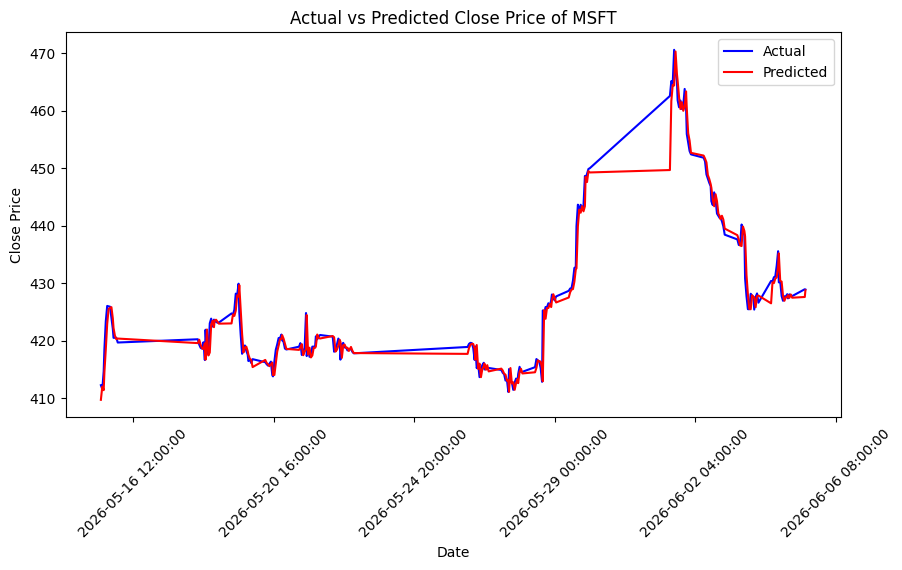

In [6]:
# create a simple linear regression model to predict the close price based on the previous 24 hours

# create a new dataframe with the close price of the previous 24 hours as features and the close price of the current hour as target
df_features = pd.DataFrame()
for i in range(1, 3):
    df_features[f'close_{i}'] = df['close'].shift(i)
    df_features[f'volume_{i}'] = df['volume'].shift(i)
    df_features[f'low_{i}'] = df['low'].shift(i)
    df_features[f'high_{i}'] = df['high'].shift(i)
    df_features[f'open_{i}'] = df['open'].shift(i) 
df_features['target'] = df['close']
df_features['datetime'] = df['datetime']

# drop rows with NaN values
df_features.dropna(inplace=True)
df_features = df_features.copy()
dates = df_features['datetime']
df_features.drop('datetime', axis=1, inplace=True)

# print number of rows and columns in the dataframe
print(f'Number of rows: {df_features.shape[0]}')
print(f'Number of columns: {df_features.shape[1]}')
#print(df_features)

# split the data into train and test sets
X = df_features.drop('target', axis=1)
y = df_features['target']
# do a train test split with the first 80% of the data in the train set and the last 20% of the data in the test set, not random
split = 0.8
X_train = X[:int(split*len(X))]
y_train = y[:int(split*len(y))]
X_test = X[int(split*len(X)):]
y_test = y[int(split*len(y)):]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Number of rows in train set: {X_train.shape[0]}')
print(f'Number of rows in test set: {X_test.shape[0]}')
# create a linear regression model
model = LinearRegression()
# fit the model on the training data
model.fit(X_train, y_train)
# evaluate the model on the test data
score = model.score(X_test, y_test)
print(f'R^2 score: {score}')    

# compute the root mean squared error of the model
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
print(f'RMSE: {rmse}')

# create a dataframe with the actual and predicted values of the test set and the corresponding dates
chart_data = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}, index=dates[int(split*len(X)):])

# plot the predicted values against the actual values over time with timestamps on the x-axis and close price on the y-axis, where the predicted value is red and the actual value is blue and format the x axis to show the date and time
plt.figure(figsize=(10,5))
plt.plot(chart_data.index, chart_data['Actual'], label='Actual', color='blue')
plt.plot(chart_data.index, chart_data['Predicted'], label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Close Price of MSFT')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=100))
plt.xticks(rotation=45)
plt.legend()
plt.show()  


In [7]:

# Nieuwste voorspelling printen met datum en tijd
print(chart_data['Predicted'].iloc[-1])
print(chart_data.index[-1])


428.7568904722355
2026-06-05 10:26:41


## Dashboard

In [8]:
import streamlit as st

In [9]:
st.line_chart(chart_data)

2026-06-05 10:45:29.024 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 10:45:29.567 
  command:

    streamlit run C:\Users\k.heidekamp\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-05 10:45:29.568 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-05 10:45:29.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()